# Vector Spaces, Subspaces, and Span

A computational companion to [Vector Spaces, Subspaces, and Span](https://fjhickernell.github.io/MATH332Fall2026/slides/06-general-vector-spaces.html). Experiment with polynomial and function vectors, closure tests, and spans beyond coordinate columns.

The deck supplies the mathematical exposition. Predict each result before running its cell; use exact SymPy calculations to check your reasoning. Numerical plots illustrate the examples rather than prove general statements.

## Running this notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH332Fall2026/blob/main/notebooks/demonstrations/06-general-vector-spaces.ipynb)

Run all cells in order with the **qmcpy** kernel. The setup cell changes the environment only in Colab, where it installs the course's recorded `classlib` checkout. It leaves the working directory unchanged. Colab does not save edits to the course repository; save a copy in Drive to retain your experiments.

In [1]:
from pathlib import Path
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib; this may take a minute …")
    course_checkout = Path("/content/MATH332Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH332Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "submodule", "update", "--init", "--recursive", "classlib",
        ],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", str(course_checkout / "classlib")],
        check=True,
    )
    print("Colab setup complete.")

In [2]:
import numpy as np
import sympy as sp
from sympy import Matrix
import matplotlib.pyplot as plt
import classlib as cl
from IPython.display import display, Markdown

%matplotlib inline
cl.nbviz.init(use_tex=False)
sp.init_printing()
np.set_printoptions(precision=5, suppress=True)
colors = [cl.nbviz.TOL_BRIGHT["blue"], cl.nbviz.TOL_BRIGHT["red"]]
t = sp.symbols("t", real=True)

def show(label, value):
    display(Markdown(label))
    display(value)


## 1. Polynomials are vectors

Use the usual polynomial operations in $\mathbb{P}_3$, the real polynomials of degree at most three. Test a general linear combination of $p=t+t^3$ and $q=2t-t^2$: what happens to the constant term?

In [3]:
c, d = sp.symbols("c d", real=True)
p, q = t+t**3, 2*t-t**2
combination = sp.expand(c*p+d*q)
show("A general linear combination", combination)
assert combination.subs(t, 0) == 0
print("Its constant term is zero for all real c,d.")


A general linear combination

Its constant term is zero for all real c,d.


### A constraint becomes an exact calculation

In $\mathbb{P}_3$, let $W=\{p:p(1)=0\}$. The deck proves closure. Compute a spanning list by applying the constraint to the coefficient column $(a_0,a_1,a_2,a_3)^{\mathsf T}$, then reconstruct a general member.

In [4]:
evaluation = Matrix([[1, 1, 1, 1]])
W_coefficients = Matrix.hstack(*evaluation.nullspace())
monomials = Matrix([[1, t, t**2, t**3]])
W_polynomials = monomials*W_coefficients
show("Spanning polynomials (as a row)", W_polynomials)
alpha = Matrix(sp.symbols("alpha0:3", real=True))
general_member = sp.expand((W_polynomials*alpha)[0])
assert sp.simplify(general_member.subs(t, 1)) == 0
show("A general member", sp.factor(general_member))
show("Constraint applied to the spanning columns", evaluation*W_coefficients)


Spanning polynomials (as a row)

A general member

Constraint applied to the spanning columns

## 2. Membership in a polynomial span

Use $p_1=1+t$, $p_2=t+t^2$. Match coefficients in $c_1p_1+c_2p_2=p$. Predict whether $2+3t+t^2$ and $1$ belong to the span. The coefficient order is $1,t,t^2$.

In [5]:
def coefficients(poly, degree):
    return Matrix([sp.expand(poly).coeff(t, j) for j in range(degree+1)])

generators = (1+t, t+t**2)
P = Matrix.hstack(*(coefficients(poly, 2) for poly in generators))
c1, c2 = sp.symbols("c1 c2", real=True)
for target in (2+3*t+t**2, sp.Integer(1)):
    solutions = sp.linsolve((P, coefficients(target, 2)), (c1, c2))
    show(f"Coefficient solutions for {target}", solutions)
a0, a1, a2 = sp.symbols("a0 a1 a2", real=True)
relation = (P.T.nullspace()[0].T*Matrix([a0, a1, a2]))[0]
show("Membership condition: this expression must equal zero", relation)
assert sp.linsolve((P, coefficients(2+3*t+t**2, 2))) == sp.FiniteSet((2, 1))
assert sp.linsolve((P, coefficients(sp.Integer(1), 2))) == sp.EmptySet


Coefficient solutions for t**2 + 3*t + 2

Coefficient solutions for 1

Membership condition: this expression must equal zero

## 3. A plane through the origin and an affine plane

Compare $z=x+y$ with $z=x+y+1$ in $\mathbb{R}^3$. Test a general linear combination symbolically, then compare the pictures. The second plane fails the zero-vector test under ordinary operations.

Affine combination: z-x-y (must be 1 for membership)

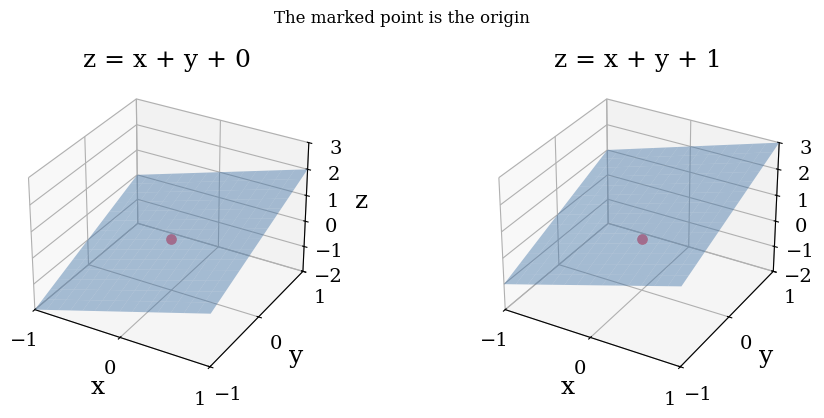

In [6]:
x1, y1, x2, y2 = sp.symbols("x1 y1 x2 y2", real=True)
u = Matrix([x1, y1, x1+y1])
v = Matrix([x2, y2, x2+y2])
combined = c*u+d*v
assert sp.expand(combined[2]-combined[0]-combined[1]) == 0
affine_combined = c*(u+Matrix([0,0,1]))+d*(v+Matrix([0,0,1]))
show("Affine combination: z-x-y (must be 1 for membership)",
     sp.expand(affine_combined[2]-affine_combined[0]-affine_combined[1]))

grid = np.linspace(-1, 1, 15)
xx, yy = np.meshgrid(grid, grid)
fig = plt.figure(figsize=(10,4))
for k, offset in enumerate((0,1), start=1):
    ax = fig.add_subplot(1,2,k,projection="3d")
    ax.plot_surface(xx,yy,xx+yy+offset,alpha=0.45,color=colors[0])
    ax.scatter([0],[0],[0],color=colors[1],s=45)
    ax.set(xlabel="x",ylabel="y",zlabel="z",title=f"z = x + y + {offset}",
           xlim=(-1,1),ylim=(-1,1),zlim=(-2,3))
    ax.set_xticks([-1,0,1])
    ax.set_yticks([-1,0,1])
fig.suptitle("The marked point is the origin")
plt.tight_layout()
plt.show()


## 4. Functions and affine differential-equation solutions

The deck uses $h''-h=0$ and $h''-h=1$. Verify the homogeneous family and the translated family $-1+ae^t+be^{-t}$. Check what happens when two members of the translated family are added.

In [7]:
a, b = sp.symbols("a b", real=True)
homogeneous = a*sp.exp(t)+b*sp.exp(-t)
particular = -sp.Integer(1)
affine = particular+homogeneous
def L(h):
    return sp.simplify(sp.diff(h,t,2)-h)
assert L(homogeneous) == 0 and L(affine) == 1
show("L(h) for the homogeneous family", L(homogeneous))
show("L(h) for the affine family", L(affine))
show("L(2h): addition need not stay in L(h)=1", L(2*affine))
show("L(0): the zero function fails the nonhomogeneous equation", L(sp.Integer(0)))


L(h) for the homogeneous family

L(h) for the affine family

L(2h): addition need not stay in L(h)=1

L(0): the zero function fails the nonhomogeneous equation

## 5. The operations matter

The deck defines $u\boxplus v=u+v-(1,1)^{\mathsf T}$. Find its additive identity, and check why pairing this addition with ordinary scalar multiplication fails distributivity. One counterexample is enough to reject these proposed vector-space operations.

2(u boxplus v)

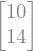

(2u) boxplus (2v)

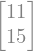

In [8]:
u = Matrix([2,3])
v = Matrix([4,5])
shift = Matrix([1,1])
def boxplus(u,v):
    return u+v-shift
assert boxplus(u,shift) == u
left, right = 2*boxplus(u,v), boxplus(2*u,2*v)
show("2(u boxplus v)", left)
show("(2u) boxplus (2v)", right)
assert left != right


## Your experiments

1. Replace $p(1)=0$ by $p(1)=2$ in Section 1. Test zero and addition. Describe the result as a particular polynomial plus the homogeneous directions.
2. Replace the polynomial generators in Section 2. Predict a membership condition before asking SymPy.
3. Test shifted scalar multiplication $c\odot u=cu+(1-c)(1,1)^{\mathsf T}$ with `boxplus`. Translate by $(1,1)^{\mathsf T}$ to explain the structure; numerical tests alone cannot prove all axioms.

Return to the deck for the general closure arguments. Symbolic calculations can verify identities in these examples; plots and isolated numerical tests cannot prove a universal closure claim.

In [9]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(
    "Total execution time for this notebook is "
    f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec."
)

Total execution time for this notebook is 0 min 4.9 sec.
